# PINN experiment notebook

In [85]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

from data_generation import get_initial_condition, get_time_sampling
from net import PINN
from train_test import train_loop

sns.set()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
# get the initial conditions, and the training input for the Net
initial_conditions = get_initial_condition()
input = get_time_sampling()
print(initial_conditions)
print(input.shape)

{'time-positon': (0, 1), 'time-speed': (0, 1)}
torch.Size([50, 1])


In [87]:
# get model
model = PINN()
print(model)

PINN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


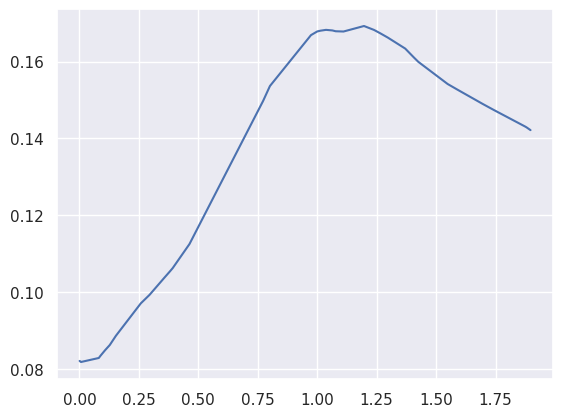

In [88]:
# see initial result for model output
output = model(input)
# As the output is one-dimensional, we can easily visualize it with respect to the input
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

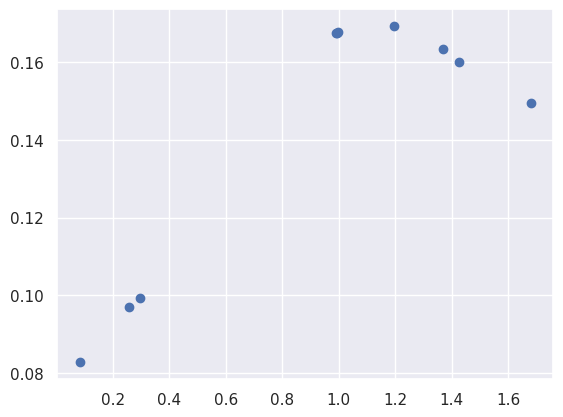

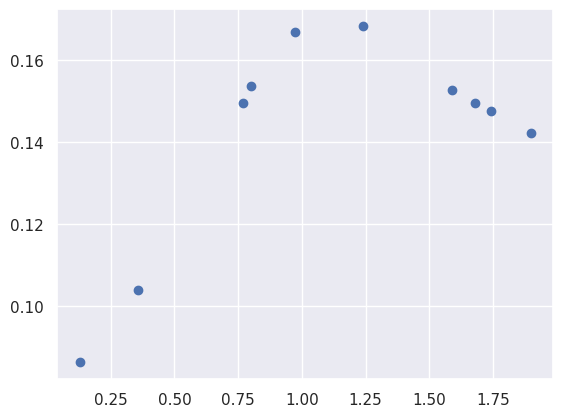

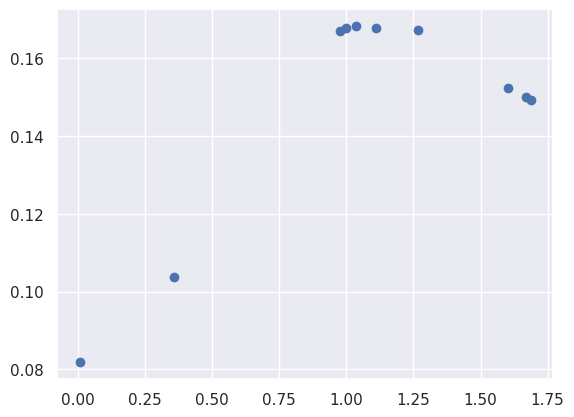

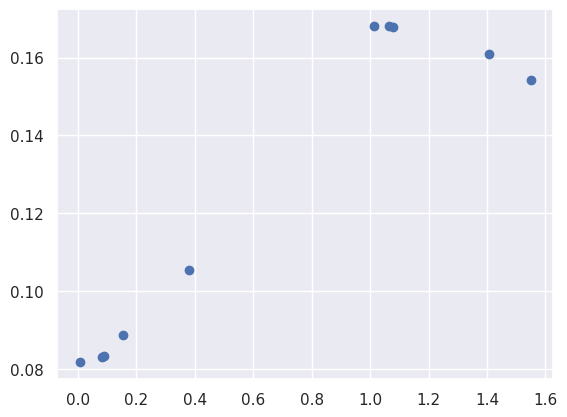

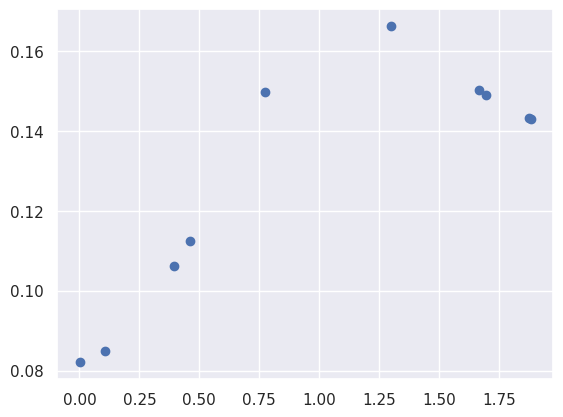

In [89]:
train_loop(input, model, 8, 3)